# PowerCo – Exploratory Data Analysis

## Task 2: Exploratory Data Analysis and Data Cleaning

**Objective:** Understand the structure, data types, distributions and basic data quality of the PowerCo customer and historical pricing datasets, with particular attention to the churn indicator.

The analysis follows the starter notebook provided by Estelle and focuses on descriptive statistics and simple visualizations.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

%matplotlib inline
sns.set(color_codes=True)

In [2]:
client_df = pd.read_csv('./client_data.csv')
price_df = pd.read_csv('./price_data.csv')

print("Client data shape:", client_df.shape)
print("Price data shape:", price_df.shape)

Client data shape: (14606, 26)
Price data shape: (193002, 8)


In [3]:
client_df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


In [4]:
price_df.head(3)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


In [5]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [6]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


In [7]:
# Convert date fields to datetime for analysis
client_date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
price_date_cols = ['price_date']

for col in client_date_cols:
    client_df[col] = pd.to_datetime(client_df[col], errors='coerce')

for col in price_date_cols:
    price_df[col] = pd.to_datetime(price_df[col], errors='coerce')

print("Client date columns:")
print(client_df[client_date_cols].dtypes)
print("\nPrice date column:")
print(price_df[price_date_cols].dtypes)

Client date columns:
date_activ         datetime64[ns]
date_end           datetime64[ns]
date_modif_prod    datetime64[ns]
date_renewal       datetime64[ns]
dtype: object

Price date column:
price_date    datetime64[ns]
dtype: object


### Data quality checks

In [8]:
print("Missing values in client data:")
display(client_df.isnull().sum().sort_values(ascending=False))

print("\nMissing values in price data:")
display(price_df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows in client data:", client_df.duplicated().sum())
print("Duplicate rows in price data:", price_df.duplicated().sum())

Missing values in client data:


id                                0
channel_sales                     0
pow_max                           0
origin_up                         0
num_years_antig                   0
net_margin                        0
nb_prod_act                       0
margin_net_pow_ele                0
margin_gross_pow_ele              0
imp_cons                          0
has_gas                           0
forecast_price_pow_off_peak       0
forecast_price_energy_peak        0
forecast_price_energy_off_peak    0
forecast_meter_rent_12m           0
forecast_discount_energy          0
forecast_cons_year                0
forecast_cons_12m                 0
date_renewal                      0
date_modif_prod                   0
date_end                          0
date_activ                        0
cons_last_month                   0
cons_gas_12m                      0
cons_12m                          0
churn                             0
dtype: int64


Missing values in price data:


id                    0
price_date            0
price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
price_off_peak_fix    0
price_peak_fix        0
price_mid_peak_fix    0
dtype: int64


Duplicate rows in client data: 0
Duplicate rows in price data: 0


---

## 3. Descriptive statistics

`describe()` provides counts, central tendency and spread for numerical variables and helps identify variables with large ranges or potential skew/outliers.

In [9]:
client_df.describe().T

,count,mean,min,25%,50%,75%,max,std
cons_12m,14606.0,159220.286252,0.0,5674.75,14115.5,40763.75,6207104.0,573465.264198
cons_gas_12m,14606.0,28092.375325,0.0,0.0,0.0,0.0,4154590.0,162973.059057
cons_last_month,14606.0,16090.269752,0.0,0.0,792.5,3383.0,771203.0,64364.196422
date_activ,14606,2011-01-28 07:54:18.879912448,2003-05-09 00:00:00,2010-01-15 00:00:00,2011-03-04 00:00:00,2012-04-19 00:00:00,2014-09-01 00:00:00,NaN
date_end,14606,2016-07-27 20:48:26.422018560,2016-01-28 00:00:00,2016-04-27 06:00:00,2016-08-01 00:00:00,2016-10-31 00:00:00,2017-06-13 00:00:00,NaN
date_modif_prod,14606,2013-01-02 12:29:10.951663872,2003-05-09 00:00:00,2010-08-12 00:00:00,2013-06-19 00:00:00,2015-06-16 00:00:00,2016-01-29 00:00:00,NaN
date_renewal,14606,2015-07-21 06:59:00.353279488,2013-06-26 00:00:00,2015-04-17 00:00:00,2015-07-27 00:00:00,2015-10-29 00:00:00,2016-01-28 00:00:00,NaN
forecast_cons_12m,14606.0,1868.61488,0.0,494.995,1112.875,2401.79,82902.83,2387.571531
forecast_cons_year,14606.0,1399.762906,0.0,0.0,314.0,1745.75,175375.0,3247.786255
forecast_discount_energy,14606.0,0.966726,0.0,0.0,0.0,0.0,30.0,5.108289


In [10]:
price_df.describe().T

,count,mean,min,25%,50%,75%,max,std
price_date,193002,2015-06-16 12:50:49.933161216,2015-01-01 00:00:00,2015-04-01 00:00:00,2015-07-01 00:00:00,2015-10-01 00:00:00,2015-12-01 00:00:00,NaN
price_off_peak_var,193002.0,0.141027,0.0,0.125976,0.146033,0.151635,0.2807,0.025032
price_peak_var,193002.0,0.05463,0.0,0.0,0.085483,0.101673,0.229788,0.049924
price_mid_peak_var,193002.0,0.030496,0.0,0.0,0.0,0.072558,0.114102,0.036298
price_off_peak_fix,193002.0,43.334477,0.0,40.728885,44.26693,44.44471,59.44471,5.410297
price_peak_fix,193002.0,10.622875,0.0,0.0,0.0,24.339581,36.490692,12.841895
price_mid_peak_fix,193002.0,6.409984,0.0,0.0,0.0,16.226389,17.458221,7.773592


### Categorical variables

In [11]:
categorical_cols = client_df.select_dtypes(include='object').columns

categorical_summary = pd.DataFrame({
    'data_type': client_df[categorical_cols].dtypes.astype(str),
    'unique_values': client_df[categorical_cols].nunique(dropna=False),
    'missing_values': client_df[categorical_cols].isna().sum()
})

categorical_summary

,data_type,unique_values,missing_values
id,object,14606,0
channel_sales,object,8,0
has_gas,object,2,0
origin_up,object,6,0


In [12]:
churn_counts = client_df['churn'].value_counts().sort_index()
churn_percentage = client_df['churn'].value_counts(normalize=True).sort_index() * 100

pd.DataFrame({
    'count': churn_counts,
    'percentage': churn_percentage.round(2)
}, index=['Retention (0)', 'Churn (1)'])

,count,percentage
Retention (0),NaN,NaN
Churn (1),NaN,NaN


---

## 4. Data visualization

The visualizations below focus on simple distributions and the churn split, as recommended in the task instructions.

In [13]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )
    annotate_stacked_bars(ax, textsize=14)
    plt.legend(["Retention", "Churn"], loc=legend_)
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    for p in ax.patches:
        value = str(round(p.get_height(), 1))
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x() + p.get_width()/2) * pad - 0.05,
             (p.get_y() + p.get_height()/2) * pad),
            color=colour,
            size=textsize
        )

def plot_distribution(dataframe, column, ax, bins_=50):
    temp = pd.DataFrame({
        "Retention": dataframe[dataframe["churn"] == 0][column],
        "Churn": dataframe[dataframe["churn"] == 1][column]
    })
    temp[["Retention", "Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    ax.set_title(f"Distribution of {column} by churn status")
    ax.set_xlabel(column)

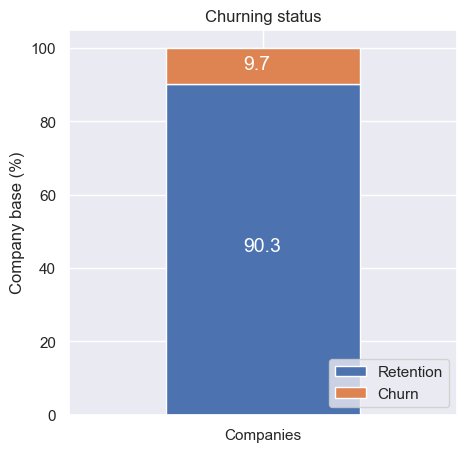

In [14]:
# Churn distribution
churn = client_df[['id', 'churn']].copy()
churn.columns = ['Companies', 'churn']

churn_total = churn.groupby('churn').count()
churn_percentage = churn_total / churn_total.sum() * 100

plot_stacked_bars(
    churn_percentage.transpose(),
    "Churning status",
    (5, 5),
    legend_="lower right"
)

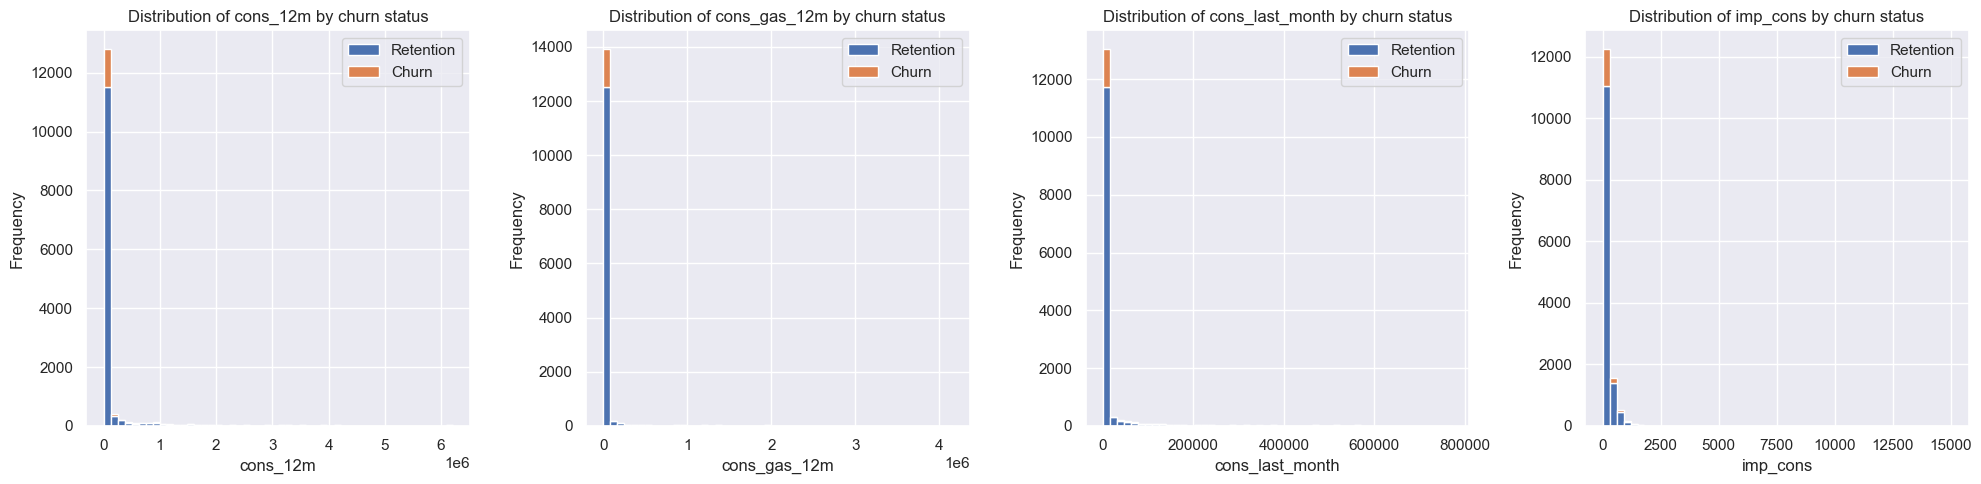

In [15]:
# Distributions of selected consumption variables
distribution_cols = [
    'cons_12m',
    'cons_gas_12m',
    'cons_last_month',
    'imp_cons'
]

fig, axs = plt.subplots(nrows=1, ncols=len(distribution_cols), figsize=(20, 5))

for ax, col in zip(axs, distribution_cols):
    plot_distribution(client_df, col, ax)

plt.tight_layout()
plt.show()

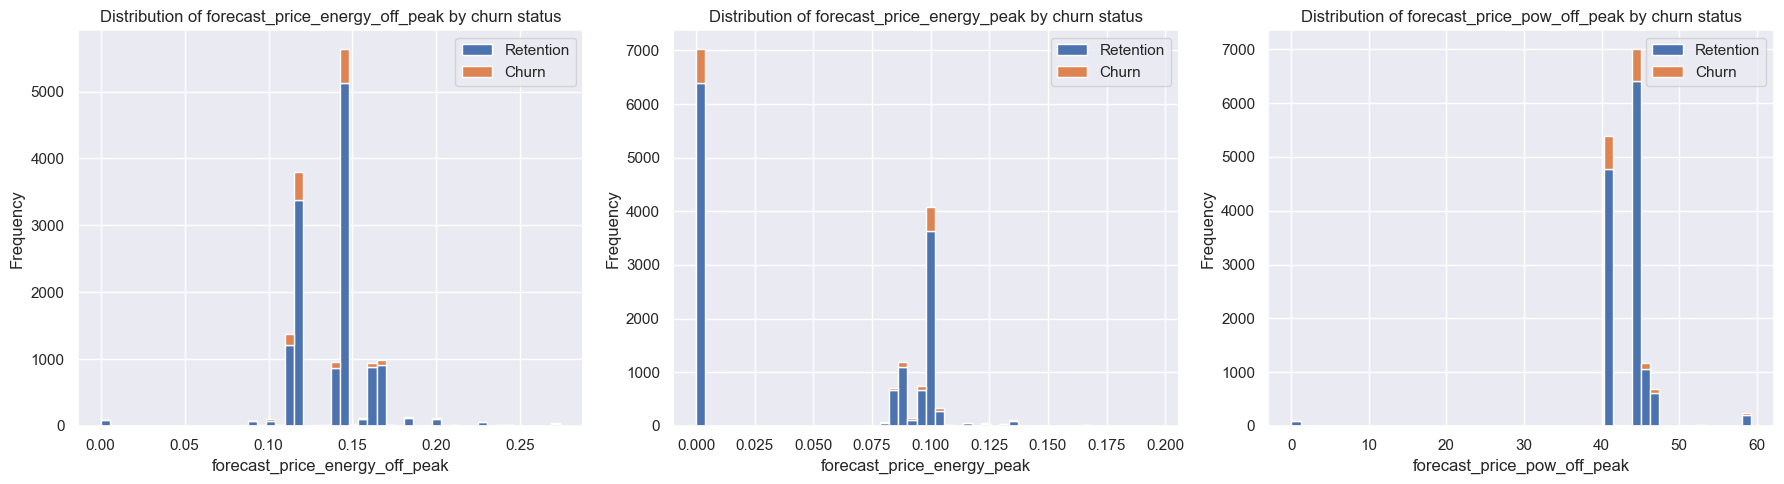

In [16]:
# Distributions of key forecast price variables
price_cols = [
    'forecast_price_energy_off_peak',
    'forecast_price_energy_peak',
    'forecast_price_pow_off_peak'
]

fig, axs = plt.subplots(nrows=1, ncols=len(price_cols), figsize=(18, 5))

for ax, col in zip(axs, price_cols):
    plot_distribution(client_df, col, ax)

plt.tight_layout()
plt.show()

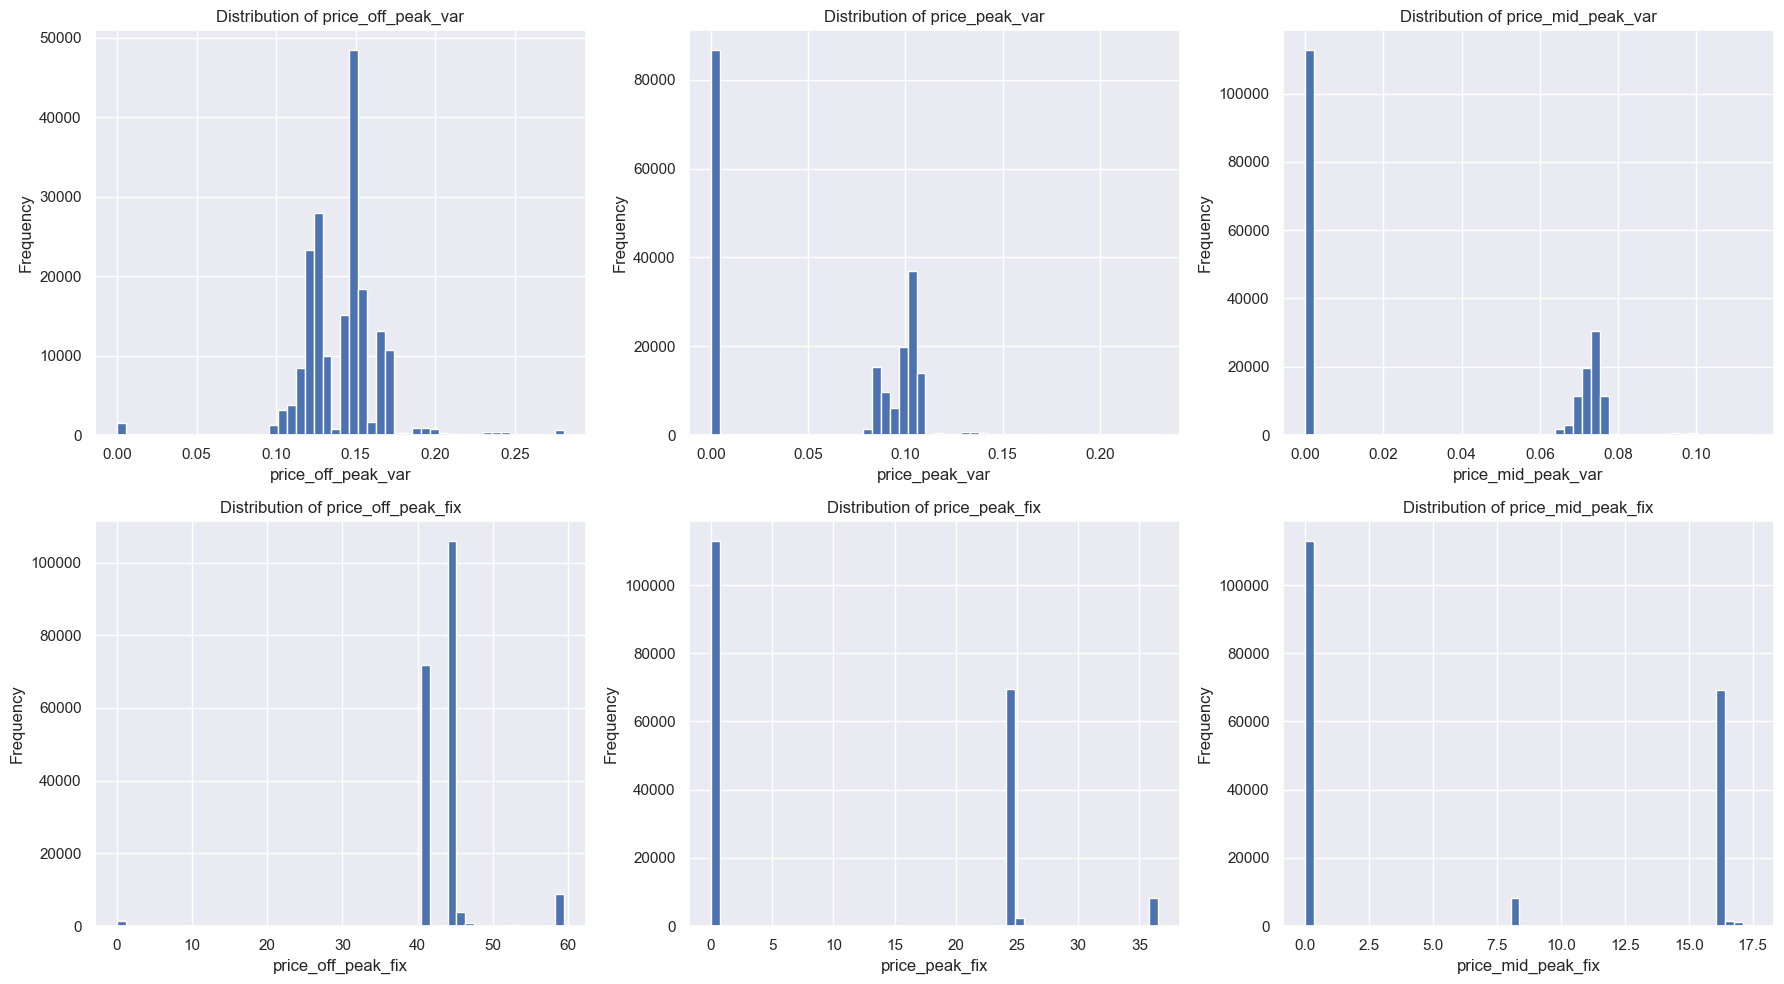

In [17]:
# Historical price distributions
historical_price_cols = [
    'price_off_peak_var',
    'price_peak_var',
    'price_mid_peak_var',
    'price_off_peak_fix',
    'price_peak_fix',
    'price_mid_peak_fix'
]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

for ax, col in zip(axs.flatten(), historical_price_cols):
    price_df[col].plot(kind='hist', bins=50, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()